# Week 5 · Lab — Swarm Showdown

**Goals**
- Compare three PSO variants, ACO$_\mathbb{R}$ and a (1+1)-ES baseline on a shifted and shifted-rotated benchmark
  suite in $d=10$ and $d=30$, at equal evaluation budgets, with multi-seed statistics.
- Report the results the way benchmarking papers should: convergence curves with IQR bands and empirical cumulative
  distributions (ECDFs) of runtimes over (problem, target) pairs.
- Quantify rotation (in)variance and explain it by the mechanisms (coordinate-wise randomness vs isotropic mutation).
- Apply PSO to an AI task: tuning four hyperparameters of a kernel ridge regression model by leave-one-out
  cross-validation, against random search at equal budgets.

**Prerequisites:** Notebooks 1–4 of this week; Week 1 (benchmarks, budgets).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from utils import (BENCHMARKS, BudgetedObjective, shifted_rotated, random_rotation, best_so_far_on_grid, PALETTE,
                   sphere, ellipsoid, rastrigin, ackley, rosenbrock)
from scipy.stats import mannwhitneyu

## 1. The contestants

All algorithms are vectorised over independent runs and count evaluations explicitly; each returns the evaluation
count at every trace point and the best-so-far value of every run.

| name | mechanism summary | parameters |
|---|---|---|
| PSO-constr gbest | constriction PSO, global information graph | $w=0.7298$, $c=1.49618$, $n=40$ |
| PSO-constr ring | same, ring graph (slower information flow) | same |
| PSO-LDIW gbest | inertia $w:0.9\to0.4$ linearly, $c=2$, $v_{\max}=x_{\max}$ (Shi & Eberhart 1998/1999) | $n=40$ |
| ACO$_\mathbb{R}$ | archive of $k$ ranked solutions, Gaussian sampling around a rank-selected guide (Socha & Dorigo 2008) | $k=50$, $m=2$, $q=10^{-4}$, $\xi=0.85$ |
| (1+1)-ES | one parent, isotropic Gaussian mutation, elitist acceptance, 1/5 success rule (Rechenberg 1973) | $\sigma_0=0.3\,(u-\ell)$ |

The (1+1)-ES uses a smooth form of the 1/5 rule: after each trial $\log\sigma$ increases by $1/D$ on success and
decreases by $1/(4D)$ on failure ($D=\sqrt{d+1}$), so $\sigma$ is stationary exactly at success rate $1/5$. Its mutation
distribution is isotropic, so apart from the axis-aligned box and initialisation it is **rotation invariant**, which
makes it the natural control for the rotation experiment. All methods clip to the box (PSO also zeroes the velocity
component: the absorbing rule of Notebook 1).

In [2]:
def pso(f, d, lo, hi, budget, runs, rng, n=40, w=0.7298, c=1.49618, topology="gbest", vmax=None):
    X = rng.uniform(lo, hi, (runs, n, d)); V = (rng.uniform(lo, hi, (runs, n, d)) - X) / 2
    Pf = f(X.reshape(-1, d)).reshape(runs, n); P = X.copy()
    ar, idx = np.arange(runs)[:, None], np.arange(n)
    nbr = np.stack([(idx - 1) % n, idx, (idx + 1) % n], 1) if topology == "ring" else None
    T = budget // n
    grid, trace = [n], [Pf.min(1)]
    for t in range(1, T):
        gi = np.broadcast_to(Pf.argmin(1)[:, None], (runs, n)) if nbr is None else nbr[idx, Pf[:, nbr].argmin(2)]
        wt = w(t / (T - 1)) if callable(w) else w
        r = rng.random((2, runs, n, d))
        V = wt * V + c * r[0] * (P - X) + c * r[1] * (P[ar, gi] - X)
        if vmax is not None:
            V = np.clip(V, -vmax * (hi - lo), vmax * (hi - lo))
        Xn = X + V; out = (Xn < lo) | (Xn > hi)
        X, V = np.clip(Xn, lo, hi), np.where(out, 0.0, V)
        F = f(X.reshape(-1, d)).reshape(runs, n)
        imp = F < Pf; P[imp], Pf[imp] = X[imp], F[imp]
        grid.append(n * (t + 1)); trace.append(Pf.min(1))
    b = Pf.argmin(1)
    return dict(grid=np.array(grid), trace=np.array(trace).T, best_x=P[np.arange(runs), b])


def aco_r(f, d, lo, hi, budget, runs, rng, k=50, m=2, q=1e-4, xi=0.85):
    A = rng.uniform(lo, hi, (runs, k, d))
    fA = f(A.reshape(-1, d)).reshape(runs, k)
    rr = np.arange(runs)[:, None]
    o = np.argsort(fA, 1); A, fA = A[rr, o], fA[rr, o]
    wts = np.exp(-np.arange(k) ** 2 / (2 * (q * k) ** 2)); cdf = np.cumsum(wts / wts.sum()); cdf[-1] = 1.0
    evals, grid, trace = k, [k], [fA[:, 0].copy()]
    while evals + m <= budget:
        G = A[rr, np.searchsorted(cdf, rng.random((runs, m)), side="right")]
        At = np.ascontiguousarray(A.transpose(0, 2, 1))
        sigma = xi * np.abs(At[:, None] - G[..., None]).sum(-1) / (k - 1)
        X = np.clip(G + sigma * rng.standard_normal((runs, m, d)), lo, hi)
        fX = f(X.reshape(-1, d)).reshape(runs, m); evals += m
        A2, f2 = np.concatenate([A, X], 1), np.concatenate([fA, fX], 1)
        o = np.argsort(f2, 1, kind="stable")[:, :k]
        A, fA = A2[rr, o], f2[rr, o]
        grid.append(evals); trace.append(fA[:, 0].copy())
    return dict(grid=np.array(grid), trace=np.array(trace).T, best_x=A[:, 0])


def es_one_plus_one(f, d, lo, hi, budget, runs, rng, sigma0=0.3):
    x = rng.uniform(lo, hi, (runs, d)); fx = f(x)
    sigma = np.full(runs, sigma0 * (hi - lo)); D = np.sqrt(d + 1)
    trace = np.empty((runs, budget)); trace[:, 0] = fx
    for t in range(1, budget):
        y = np.clip(x + sigma[:, None] * rng.standard_normal((runs, d)), lo, hi)
        fy = f(y); succ = fy <= fx
        x[succ], fx[succ] = y[succ], fy[succ]
        sigma *= np.exp(np.where(succ, 1.0, -0.25) / D)
        trace[:, t] = fx
    return dict(grid=np.arange(1, budget + 1), trace=trace, best_x=x)


ALGS = {
    "PSO-constr gbest": lambda f, d, lo, hi, B, R, g: pso(f, d, lo, hi, B, R, g),
    "PSO-constr ring": lambda f, d, lo, hi, B, R, g: pso(f, d, lo, hi, B, R, g, topology="ring"),
    "PSO-LDIW gbest": lambda f, d, lo, hi, B, R, g: pso(f, d, lo, hi, B, R, g, w=lambda s: 0.9 - 0.5 * s, c=2.0, vmax=0.5),
    "ACO_R": lambda f, d, lo, hi, B, R, g: aco_r(f, d, lo, hi, B, R, g),
    "(1+1)-ES": lambda f, d, lo, hi, B, R, g: es_one_plus_one(f, d, lo, hi, B, R, g),
}

## 2. Validation of the test bed and of the budget accounting

* `random_rotation` must return an orthogonal matrix, and the shifted-rotated function $g(x)=f(R(x-s))$ must attain
  $0$ at $x^{\ast}=s+R^\top x^{\ast}_f$ (for Rosenbrock $x^{\ast}_f=\mathbf 1$).
* Every algorithm, run once on an objective wrapped in `BudgetedObjective` with a budget of 3000, must never exceed
  the budget (the wrapper would raise) and must report the same best value as the wrapper recorded.
* The (1+1)-ES must converge linearly on the sphere to $f<10^{-8}$ (a known property of the 1/5 rule).

In [3]:
Rt = random_rotation(10, np.random.default_rng(1)); st = np.random.default_rng(2).uniform(-2, 2, 10)
check_close(np.abs(Rt @ Rt.T - np.eye(10)).max(), 0.0, "max |R R^T - I|", atol=1e-12)
g_ros = shifted_rotated(rosenbrock, st, Rt)
check_close(g_ros(st + Rt.T @ np.ones(10)), 0.0, "shifted-rotated Rosenbrock at s + R^T 1", atol=1e-20)
check_true(g_ros(st + Rt.T @ np.ones(10) + 1e-3) > 0, "and positive nearby")

for name, alg in ALGS.items():
    bo = BudgetedObjective(BENCHMARKS["rastrigin"].f, budget=3000)
    res = alg(bo, 10, -5.12, 5.12, 3000, 1, np.random.default_rng(3))
    check_true(bo.evals <= 3000 and res["grid"][-1] == bo.evals and res["trace"][0, -1] == bo.best_f,
               f"{name}: {bo.evals} evaluations counted by the wrapper, best value consistent")

r_es = es_one_plus_one(sphere, 10, -5.12, 5.12, 3000, 10, np.random.default_rng(4))
print(f"(1+1)-ES on the 10-D sphere after 3000 evaluations: max f over 10 runs = {r_es['trace'][:, -1].max():.1e}")
check_true(r_es["trace"][:, -1].max() < 1e-8, "(1+1)-ES with the 1/5 rule converges on the sphere")

[PASS] max |R R^T - I|: got 0.0, expected 0.0
[PASS] shifted-rotated Rosenbrock at s + R^T 1: got 0.0, expected 0.0
[PASS] and positive nearby
[PASS] PSO-constr gbest: 3000 evaluations counted by the wrapper, best value consistent
[PASS] PSO-constr ring: 3000 evaluations counted by the wrapper, best value consistent
[PASS] PSO-LDIW gbest: 3000 evaluations counted by the wrapper, best value consistent


[PASS] ACO_R: 3000 evaluations counted by the wrapper, best value consistent


[PASS] (1+1)-ES: 3000 evaluations counted by the wrapper, best value consistent


(1+1)-ES on the 10-D sphere after 3000 evaluations: max f over 10 runs = 6.0e-38
[PASS] (1+1)-ES with the 1/5 rule converges on the sphere


## 3. The suite

To avoid rewarding a bias towards the centre of the box, every function is **shifted**: $f(x-s)$ with $s$ drawn
uniformly in the central 40% of the box (Rosenbrock: $s\in[-2,2]^d$). The **rotated** twin uses the same shift and a
Haar-random rotation, $f(R(x-s))$. All optima are $f^{\ast}=0$.

* $d=10$: ellipsoid (cond. $10^6$), Rosenbrock, Rastrigin, Ackley, each shifted (S) and shifted-rotated (SR);
  budget $1000\,d=10\,000$ evaluations, 12 runs.
* $d=30$: ellipsoid and Rastrigin, S and SR; budget $500\,d=15\,000$ evaluations, 10 runs (a modest budget, chosen to
  keep the lab under 90 seconds — conclusions for $d=30$ are therefore about the early phase of the search).

**Engineering note (exact, not an approximation).** Each problem is mapped to the unit cube,
$\tilde f(u)=f(\ell+u\,(u_{\max}-\ell))$. All five algorithms are equivariant under this affine map (uniform
initialisation in the box, velocity/step sizes and clipping expressed relative to the box), so this changes nothing
but lets us **stack** all (problem, run) pairs into one vectorised call: run $r$ of problem $p$ is row block
$p\cdot R+r$, and a stacked objective splits every batch into $P$ contiguous chunks (all algorithms order rows
run-major). We verify the stacked objective against per-problem evaluation.

In [4]:
def make_suite(d, names, seed):
    g = np.random.default_rng(seed)
    R = random_rotation(d, g)
    suite = {}
    for nm in names:
        bm = BENCHMARKS[nm]
        s = g.uniform(-2, 2, d) if nm == "rosenbrock" else g.uniform(0.4 * bm.lower, 0.4 * bm.upper, d)
        for tag, rot in [("S", np.eye(d)), ("SR", R)]:
            f = shifted_rotated(bm.f, s, rot)
            suite[f"{nm} {tag}"] = (lambda U, f=f, lo=bm.lower, hi=bm.upper: f(lo + U * (hi - lo)))
    return suite


def stacked(fs):
    """Objective for P problems stacked along the run axis: the batch is split into P contiguous chunks."""
    def g(U):
        U = np.atleast_2d(U)
        return np.concatenate([f(c) for f, c in zip(fs, np.split(U, len(fs)))])
    return g


SUITES = {10: (make_suite(10, ["ellipsoid", "rosenbrock", "rastrigin", "ackley"], 10), 10_000, 12),
          30: (make_suite(30, ["ellipsoid", "rastrigin"], 30), 15_000, 10)}
U_chk = np.random.default_rng(5).random((8 * 3, 10))
fs10 = list(SUITES[10][0].values())
direct = np.concatenate([f(U_chk[3 * p:3 * p + 3]) for p, f in enumerate(fs10)])
check_close(np.abs(stacked(fs10)(U_chk) - direct).max(), 0.0, "stacked objective vs per-problem evaluation", atol=0)

results = {}
for d, (suite, B, R_) in SUITES.items():
    names, P = list(suite), len(suite)
    for ai, (aname, alg) in enumerate(ALGS.items()):
        res = alg(stacked(list(suite.values())), d, 0.0, 1.0, B, P * R_, np.random.default_rng(1000 * d + ai))
        for p, pname in enumerate(names):
            results[d, pname, aname] = dict(grid=res["grid"], trace=res["trace"][p * R_:(p + 1) * R_])

for d, (suite, B, R_) in SUITES.items():
    print(f"\nd = {d}: final error f - f*, median [IQR] over {R_} runs, budget {B}")
    print(f"{'problem':15s}" + "".join(f"{a:>26s}" for a in ALGS))
    for pname in suite:
        row = ""
        for aname in ALGS:
            e = results[d, pname, aname]["trace"][:, -1]
            q1, m_, q3 = np.percentile(e, [25, 50, 75])
            row += f"{m_:>11.1e} [{q1:.0e},{q3:.0e}]"
        print(f"{pname:15s}" + row)

[PASS] stacked objective vs per-problem evaluation: got 0.0, expected 0.0



d = 10: final error f - f*, median [IQR] over 12 runs, budget 10000
problem                  PSO-constr gbest           PSO-constr ring            PSO-LDIW gbest                     ACO_R                  (1+1)-ES
ellipsoid S        2.1e-07 [2e-08,2e-05]    6.3e-03 [3e-03,9e-03]    1.2e-03 [2e-04,2e+01]    4.7e-26 [4e-26,5e-26]    4.2e+02 [4e+02,7e+02]
ellipsoid SR       1.3e+03 [1e+03,2e+03]    1.6e+03 [1e+03,2e+03]    2.1e+03 [1e+03,4e+03]    8.7e+02 [5e+02,1e+03]    4.7e+02 [4e+02,9e+02]
rosenbrock S       4.7e+00 [4e+00,6e+00]    5.2e+00 [4e+00,7e+00]    6.7e+00 [5e+00,8e+00]    1.8e+00 [1e+00,5e+00]    1.4e+00 [1e+00,4e+00]
rosenbrock SR      7.5e+00 [5e+00,3e+01]    7.2e+00 [6e+00,8e+00]    8.1e+00 [7e+00,9e+00]    4.9e+00 [3e+00,8e+01]    1.4e+00 [9e-01,4e+00]
rastrigin S        5.8e+00 [3e+00,1e+01]    9.4e+00 [7e+00,1e+01]    1.0e+01 [6e+00,1e+01]    1.6e+01 [1e+01,2e+01]    7.9e+01 [5e+01,1e+02]
rastrigin SR       1.9e+01 [2e+01,2e+01]    1.9e+01 [1e+01,2e+01]    2.0e+01 [1e

## 4. Convergence curves with IQR bands

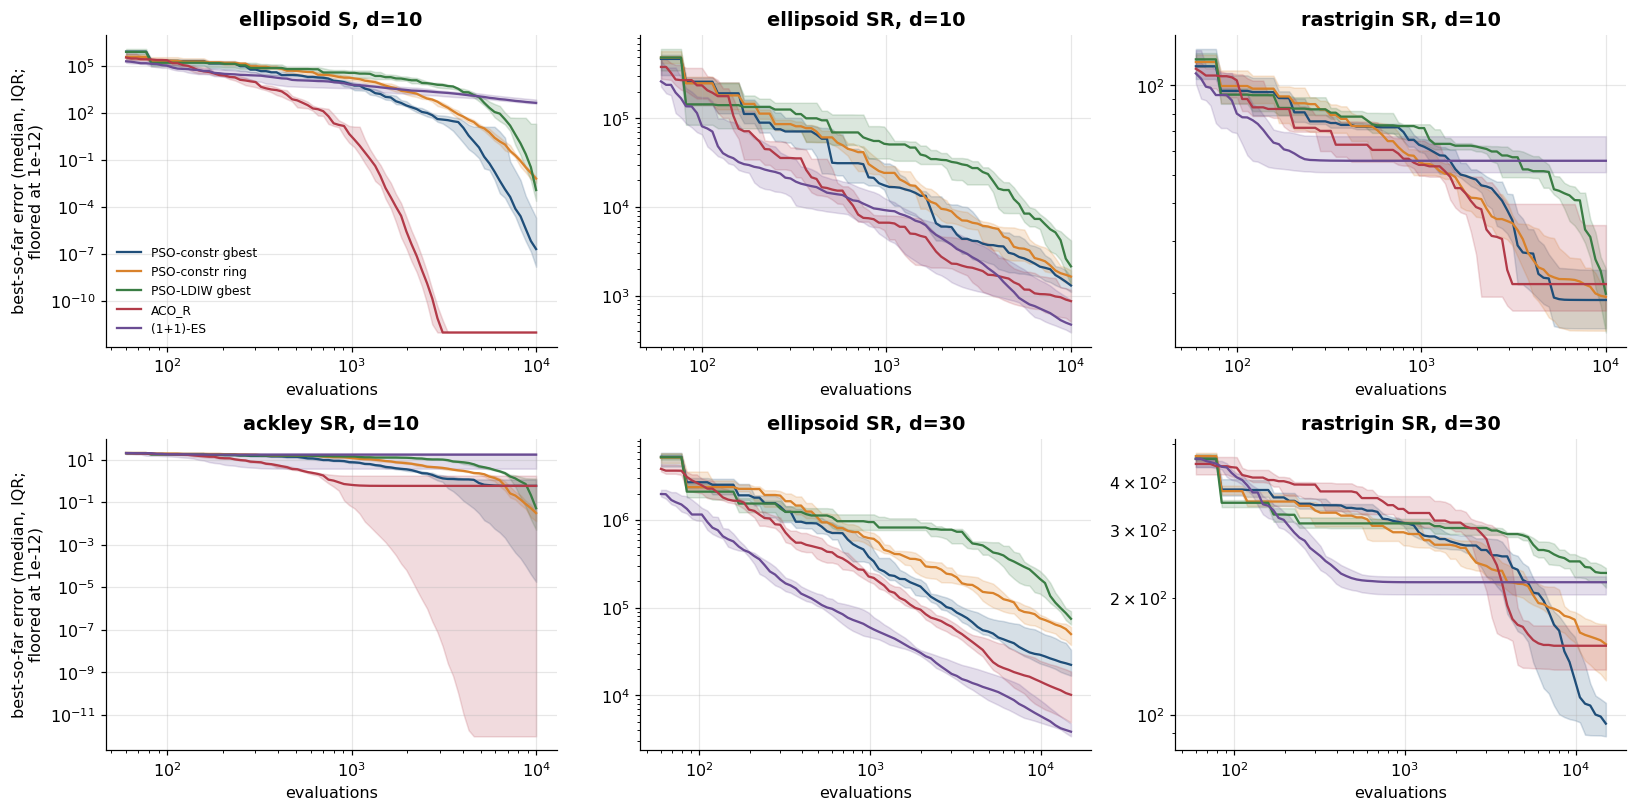

In [5]:
def on_grid(res, grid):
    return np.array([best_so_far_on_grid(res["grid"], tr, grid) for tr in res["trace"]])

show = [(10, "ellipsoid S"), (10, "ellipsoid SR"), (10, "rastrigin SR"), (10, "ackley SR"), (30, "ellipsoid SR"), (30, "rastrigin SR")]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, (d, pname) in zip(axes.ravel(), show):
    B = SUITES[d][1]
    grid = np.unique(np.logspace(np.log10(60), np.log10(B), 80).astype(int))
    for k, aname in enumerate(ALGS):
        Y = np.maximum(on_grid(results[d, pname, aname], grid), 1e-12)
        q1, m_, q3 = np.nanpercentile(Y, [25, 50, 75], axis=0)
        ax.plot(grid, m_, label=aname, color=list(PALETTE.values())[k])
        ax.fill_between(grid, q1, q3, alpha=0.18, color=list(PALETTE.values())[k])
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_title(f"{pname}, d={d}"); ax.set_xlabel("evaluations")
axes[0, 0].set_ylabel("best-so-far error (median, IQR;\nfloored at 1e-12)"); axes[1, 0].set_ylabel("best-so-far error (median, IQR;\nfloored at 1e-12)")
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); savefig("w5_lab_convergence.png"); plt.show()

## 5. Runtime ECDFs over (problem, target) pairs

Following the COCO methodology (Hansen et al. 2021, *COCO: a platform for comparing continuous optimizers in a
black-box setting*, Optimization Methods & Software 36(1)), for each problem we use 51 targets
$f^{\ast}+10^{k}$, $k\in[-8,2]$ log-uniformly spaced, and record for every run the number of evaluations at which each
target is first reached. The ECDF at budget $x$ is the fraction of all (problem, target, run) triples solved within
$x$ evaluations — an aggregate that is robust to the scale differences between functions. We normalise the budget by
$d$.

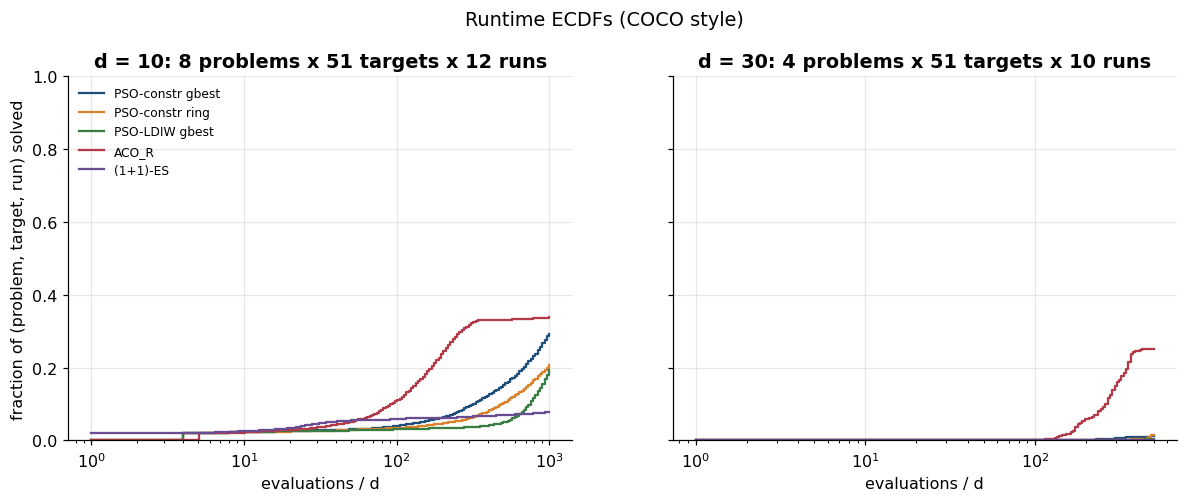

d=10: fraction of targets reached at the full budget: PSO-constr gbest 0.29, PSO-constr ring 0.21, PSO-LDIW gbest 0.19, ACO_R 0.34, (1+1)-ES 0.08
d=30: fraction of targets reached at the full budget: PSO-constr gbest 0.01, PSO-constr ring 0.02, PSO-LDIW gbest 0.01, ACO_R 0.25, (1+1)-ES 0.00


In [6]:
targets = 10.0 ** np.linspace(2, -8, 51)

def runtimes(res):
    """(runs, targets) first-hit evaluation counts (inf if never reached)."""
    hit = res["trace"][:, :, None] < targets[None, None, :]
    first = hit.argmax(1)
    return np.where(hit.any(1), res["grid"][first], np.inf)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
ecdf_final = {}
for ax, (d, (suite, B, R_)) in zip(axes, SUITES.items()):
    xs = np.logspace(0, np.log10(B / d), 200)
    for k, aname in enumerate(ALGS):
        rt = np.concatenate([runtimes(results[d, p, aname]).ravel() for p in suite]) / d
        ecdf = (rt[None, :] <= xs[:, None]).mean(1)
        ecdf_final[d, aname] = ecdf[-1]
        ax.step(xs, ecdf, where="post", label=aname, color=list(PALETTE.values())[k])
    ax.set_xscale("log"); ax.set_xlabel("evaluations / d"); ax.set_ylim(0, 1)
    ax.set_title(f"d = {d}: {len(suite)} problems x 51 targets x {R_} runs")
axes[0].set_ylabel("fraction of (problem, target, run) solved"); axes[0].legend(fontsize=8, loc="upper left")
plt.suptitle("Runtime ECDFs (COCO style)", y=1.02)
savefig("w5_lab_ecdf.png"); plt.show()
for d in SUITES:
    print(f"d={d}: fraction of targets reached at the full budget: "
          + ", ".join(f"{a} {ecdf_final[d, a]:.2f}" for a in ALGS))

## 6. Rotation invariance

For each algorithm and each S/SR pair we compare the final errors on the shifted and the shifted-rotated function
(same shift, same budget): the median ratio SR/S and the Mann–Whitney p-value.

In [7]:
pairs = [(10, "ellipsoid"), (10, "rosenbrock"), (10, "rastrigin"), (10, "ackley"), (30, "ellipsoid"), (30, "rastrigin")]
print(f"{'pair':15s}" + "".join(f"{a:>26s}" for a in ALGS))
ratio_tab = {}
for d, nm in pairs:
    row = ""
    for aname in ALGS:
        a = results[d, f"{nm} S", aname]["trace"][:, -1] + 1e-300
        b = results[d, f"{nm} SR", aname]["trace"][:, -1] + 1e-300
        ratio_tab[d, nm, aname] = np.median(b) / np.median(a)
        row += f"{ratio_tab[d, nm, aname]:>14.1e} (p={mannwhitneyu(a, b).pvalue:.0e})"
    print(f"{nm + ' d=' + str(d):15s}" + row)
check_true(ratio_tab[10, "ellipsoid", "PSO-constr gbest"] > 1e3,
           "PSO-constr gbest is > 1000x worse (median) on the rotated than on the separable ellipsoid, d=10")
check_true(ratio_tab[10, "ellipsoid", "(1+1)-ES"] < 10 and ratio_tab[10, "ellipsoid", "(1+1)-ES"] > 0.1,
           "(1+1)-ES medians on S and SR ellipsoid agree within a factor of 10, d=10")

pair                     PSO-constr gbest           PSO-constr ring            PSO-LDIW gbest                     ACO_R                  (1+1)-ES
ellipsoid d=10        6.3e+09 (p=4e-05)       2.6e+05 (p=4e-05)       1.8e+06 (p=4e-05)       1.9e+28 (p=3e-05)       1.1e+00 (p=7e-01)
rosenbrock d=10       1.6e+00 (p=1e-01)       1.4e+00 (p=6e-02)       1.2e+00 (p=1e-01)       2.8e+00 (p=2e-02)       1.0e+00 (p=9e-01)
rastrigin d=10        3.3e+00 (p=2e-03)       2.1e+00 (p=4e-04)       1.9e+00 (p=2e-03)       1.3e+00 (p=5e-02)       7.1e-01 (p=5e-01)
ackley d=10           4.0e+04 (p=3e-02)       2.6e+00 (p=2e-02)       1.3e+01 (p=3e-02)       1.5e+13 (p=1e+00)       8.6e-01 (p=5e-01)
ellipsoid d=30        1.3e+02 (p=2e-04)       1.1e+03 (p=2e-04)       1.6e+01 (p=2e-04)       7.5e+18 (p=2e-04)       1.2e+00 (p=1e-01)
rastrigin d=30        1.3e+00 (p=1e-01)       2.0e+00 (p=3e-04)       3.1e+00 (p=2e-04)       1.2e+00 (p=8e-02)       9.6e-01 (p=3e-01)
[PASS] PSO-constr gbest is > 1000x wor

**Why.** PSO draws independent $r_{1,j},r_{2,j}$ per coordinate: the new position lies in an axis-aligned box spanned by
$x$, $p$ and $l$, so its search distribution depends on the coordinate system. On a separable ill-conditioned
function this axis alignment is exactly right — each coordinate is optimised almost independently — and after rotation
it is wrong, so the performance collapses by many orders of magnitude (ellipsoid rows). ACO$_\mathbb{R}$ samples each
coordinate independently with a per-coordinate $\sigma^i$ and shows the most extreme version of the same pattern. The
(1+1)-ES mutates with an isotropic Gaussian, whose distribution is unchanged by rotation: its ratios stay close to 1
and none of its differences is significant; the box and the initialisation are its only non-invariant parts. On
Rastrigin, rotation destroys the separable grid of local minima that coordinate-wise methods exploit. For bimodal
outcomes (Ackley: some runs solve it, others stall at an error around 1) the median ratio can be huge while the
Mann–Whitney test detects nothing — look at both. **Separable benchmarks overstate the performance of
coordinate-wise methods**, which is why modern suites (CEC, BBOB) rotate their functions.

**Overall picture at these budgets (untuned default settings).**
* ACO$_\mathbb{R}$ reaches the most targets in the ECDFs of both dimensions, but mostly thanks to the *separable*
  problems (ellipsoid S, Ackley S), where it is orders of magnitude ahead; on the rotated problems its lead vanishes.
* Constriction PSO with gbest is the best or tied-best method on Rastrigin (S and SR) in both dimensions;
  the ring topology is the most reliable on rotated Ackley (tight IQR), where gbest is bimodal.
* The (1+1)-ES is the best method on Rosenbrock (S and SR) and on the rotated ellipsoid in both dimensions — its strength is
  invariance — and the weakest on the multimodal functions, where a single elitist trajectory gets trapped.
* Nobody solves the rotated ellipsoid (condition number $10^6$): that requires learning the correlations of the
  landscape, i.e. covariance matrix adaptation (CMA-ES, Week 6).

Rankings depend on the budget, the dimension and the suite: always report the full distribution, not a single winner.

## 7. AI application: PSO for hyperparameter optimisation

**Task.** Kernel ridge regression (ridge regression in the feature space of a kernel) with an *automatic relevance
determination* kernel over three feature groups,

$$
k(x,x')=\exp\Bigl(-\sum_{g=1}^{3}\gamma_g\Vert x_g-x'_g\Vert^2\Bigr),\qquad \hat f=K_{\cdot X}(K+\lambda I)^{-1}y,
$$

with four hyperparameters $\theta=(\log_{10}\lambda,\log_{10}\gamma_1,\log_{10}\gamma_2,\log_{10}\gamma_3)\in
[-6,1]\times[-3,2]^3$. The target depends strongly on group 1, weakly on group 2 and not at all on group 3, so a good
$\theta$ must *learn feature relevance* (small $\gamma_3$).

**Objective: leave-one-out cross-validation** error. With $A=K+\lambda I$ and $\alpha=A^{-1}y$, the LOO residual of
point $i$ has the closed form $e_i^{\text{LOO}}=\alpha_i/(A^{-1})_{ii}$ (because $y-\hat y=\lambda\alpha$ and
$1-H_{ii}=\lambda(A^{-1})_{ii}$ for the hat matrix $H=KA^{-1}$), so one evaluation costs one matrix inverse instead of
$n$ fits. We validate the closed form against explicit refitting.

In [8]:
def make_data(n, rng):
    X = rng.uniform(-2, 2, (n, 6))
    y = np.sin(2 * X[:, 0]) * np.cos(X[:, 1]) + 0.15 * X[:, 2] ** 2 - 0.1 * X[:, 3] + 0.3 * rng.standard_normal(n)
    return X, y

Xtr, ytr = make_data(90, np.random.default_rng(7))
Xte, yte = make_data(2000, np.random.default_rng(8))
groups = [slice(0, 2), slice(2, 4), slice(4, 6)]

def sqdist_groups(A, B):
    return np.stack([((A[:, None, g] - B[None, :, g]) ** 2).sum(-1) for g in groups])   # (3, nA, nB)

DTR = sqdist_groups(Xtr, Xtr); DTE = sqdist_groups(Xte, Xtr)

def kernel(Dg, gam):
    return np.exp(-np.tensordot(gam, Dg, axes=1))

def loo_mse(theta):
    """Closed-form LOO mean squared error of kernel ridge regression. theta: (4,) in log10 units."""
    lam, gam = 10.0 ** theta[0], 10.0 ** theta[1:]
    Ainv = np.linalg.inv(kernel(DTR, gam) + lam * np.eye(len(ytr)))
    alpha = Ainv @ ytr
    return float(np.mean((alpha / np.diag(Ainv)) ** 2))

def loo_mse_bruteforce(theta):
    lam, gam = 10.0 ** theta[0], 10.0 ** theta[1:]
    K = kernel(DTR, gam); errs = []
    for i in range(len(ytr)):
        m = np.arange(len(ytr)) != i
        a = np.linalg.solve(K[np.ix_(m, m)] + lam * np.eye(m.sum()), ytr[m])
        errs.append(ytr[i] - K[i, m] @ a)
    return float(np.mean(np.square(errs)))

def test_mse(theta):
    lam, gam = 10.0 ** theta[0], 10.0 ** theta[1:]
    a = np.linalg.solve(kernel(DTR, gam) + lam * np.eye(len(ytr)), ytr)
    return float(np.mean((kernel(DTE, gam) @ a - yte) ** 2))

th_test = np.array([-2.0, -0.3, -1.0, -2.0])
check_close(loo_mse(th_test), loo_mse_bruteforce(th_test), "closed-form LOO error vs 90 explicit refits", rtol=1e-8, atol=1e-12)

HP_LO, HP_HI = np.array([-6.0, -3, -3, -3]), np.array([1.0, 2, 2, 2])
N_LOO = [0]                                          # independent counter of LOO evaluations (one per matrix inverse)
def hp_objective(U):
    """Batch objective on the unit cube [0,1]^4 (rescaled to the hyperparameter box)."""
    U = np.atleast_2d(U)
    N_LOO[0] += len(U)
    return np.array([loo_mse(HP_LO + u * (HP_HI - HP_LO)) for u in U])

[PASS] closed-form LOO error vs 90 explicit refits: got 0.158935, expected 0.158935


**Protocol.** Budget 60 LOO evaluations per tuning run; 20 independent runs per method.
PSO: constriction gbest, 10 particles × 6 iterations, on the unit cube. Random search: 60 uniform samples.
Reference: the best value found by 4 long PSO runs (400 evaluations each) — an estimate of the attainable LOO
optimum used to report *regret*. We also report the test MSE (2000 fresh points) of each selected configuration,
which the tuner never sees.

reference LOO-MSE (best of 4 x 400-evaluation PSO runs): 0.1104   (noise variance 0.09)
  PSO            LOO-MSE median 0.1486 [IQR 0.1306, 0.1550]   regret median 0.0382   test MSE median 0.1999
  random search  LOO-MSE median 0.1661 [IQR 0.1530, 0.1774]   regret median 0.0557   test MSE median 0.2169
Mann-Whitney PSO vs random search (LOO-MSE): p = 1.5e-03
median selected log10 gamma per group (PSO): [-0.13 -1.21 -2.29]   (random search): [-0.01 -1.33 -2.07]
[PASS] both tuners used exactly 60 LOO evaluations per run (counted: 1200, 1200)


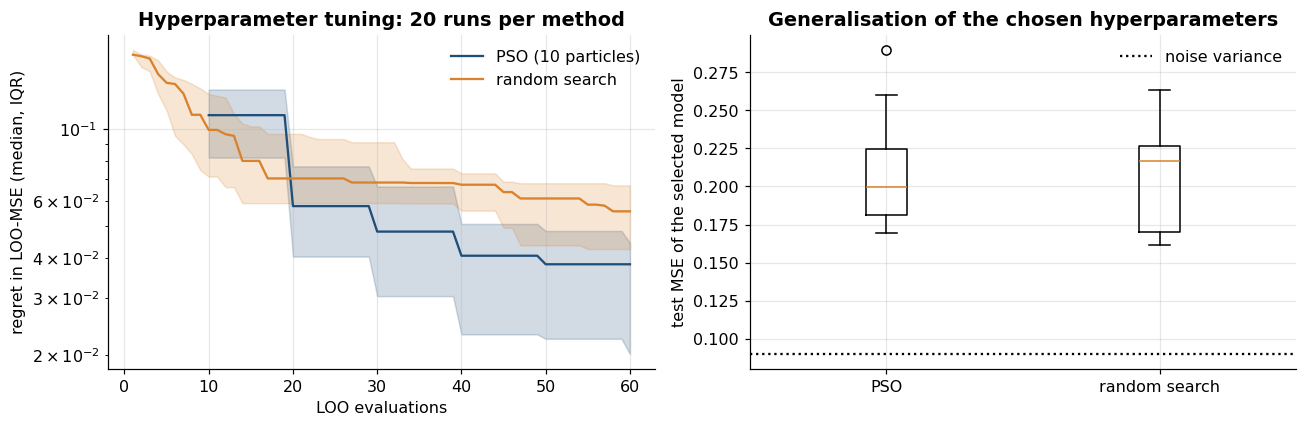

In [9]:
HB, HR = 60, 20
N_LOO[0] = 0
res_pso = pso(hp_objective, 4, 0.0, 1.0, HB, HR, np.random.default_rng(70), n=10)
n_pso = N_LOO[0]; N_LOO[0] = 0
U_rs = np.random.default_rng(71).random((HR, HB, 4))
F_rs = hp_objective(U_rs.reshape(-1, 4)).reshape(HR, HB)
n_rs = N_LOO[0]
ref = pso(hp_objective, 4, 0.0, 1.0, 400, 4, np.random.default_rng(72), n=20)
best_ref = ref["trace"][:, -1].min()
pso_best, rs_best = res_pso["trace"][:, -1], F_rs.min(1)
theta_pso = HP_LO + res_pso["best_x"] * (HP_HI - HP_LO)
theta_rs = HP_LO + U_rs[np.arange(HR), F_rs.argmin(1)] * (HP_HI - HP_LO)
te_pso = np.array([test_mse(t) for t in theta_pso]); te_rs = np.array([test_mse(t) for t in theta_rs])
print(f"reference LOO-MSE (best of 4 x 400-evaluation PSO runs): {best_ref:.4f}   (noise variance 0.09)")
for name, b, te in [("PSO", pso_best, te_pso), ("random search", rs_best, te_rs)]:
    reg = b - best_ref
    print(f"  {name:14s} LOO-MSE median {np.median(b):.4f} [IQR {np.percentile(b, 25):.4f}, {np.percentile(b, 75):.4f}]"
          f"   regret median {np.median(reg):.4f}   test MSE median {np.median(te):.4f}")
p_hpo = mannwhitneyu(pso_best, rs_best).pvalue
print(f"Mann-Whitney PSO vs random search (LOO-MSE): p = {p_hpo:.1e}")
print("median selected log10 gamma per group (PSO):", np.round(np.median(theta_pso[:, 1:], axis=0), 2),
      "  (random search):", np.round(np.median(theta_rs[:, 1:], axis=0), 2))
check_true(n_pso == n_rs == HR * HB, f"both tuners used exactly {HB} LOO evaluations per run (counted: {n_pso}, {n_rs})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rs_curve = np.minimum.accumulate(F_rs, axis=1)
ev_pso = np.arange(10, HB + 1)                      # the swarm's first trace point is after its 10 initial evaluations
pso_curve = on_grid(res_pso, ev_pso)
for k, (name, ev, Y) in enumerate([("PSO (10 particles)", ev_pso, pso_curve), ("random search", np.arange(1, HB + 1), rs_curve)]):
    q1, m_, q3 = np.percentile(Y - best_ref, [25, 50, 75], axis=0)
    axes[0].plot(ev, m_, label=name, color=list(PALETTE.values())[k]); axes[0].fill_between(ev, q1, q3, alpha=0.2, color=list(PALETTE.values())[k])
axes[0].set_yscale("log"); axes[0].set_xlabel("LOO evaluations"); axes[0].set_ylabel("regret in LOO-MSE (median, IQR)")
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
axes[0].yaxis.set_minor_formatter(LogFormatterSciNotation(labelOnlyBase=False, minor_thresholds=(2, 0.5)))
axes[0].set_title("Hyperparameter tuning: 20 runs per method"); axes[0].legend()
axes[1].boxplot([te_pso, te_rs], tick_labels=["PSO", "random search"]); axes[1].axhline(0.09, color="k", ls=":", label="noise variance")
axes[1].set_ylabel("test MSE of the selected model"); axes[1].set_title("Generalisation of the chosen hyperparameters"); axes[1].legend()
plt.tight_layout(); savefig("w5_lab_hpo.png"); plt.show()

**Interpretation.** Random search is a strong baseline in low dimension (Bergstra & Bengio 2012), and with only 60
evaluations PSO has just six iterations to exploit information; still, PSO attains a lower LOO error than random search
with a small Mann–Whitney p-value, and its selected models also have a lower median test error. The differences are
small relative to the noise variance, which is typical of hyperparameter optimisation: the objective is itself a
noisy estimate, so over-optimising it brings diminishing returns. Both tuners learn feature relevance: the selected
$\gamma_3$ (irrelevant group) is about two orders of magnitude smaller than $\gamma_1$. In practice, model-based methods
(Bayesian optimisation) are preferred at such tiny budgets, and population methods like PSO, CMA-ES and evolution
shine when evaluations are cheap or parallel (Week 6).

## Key takeaways

- At equal budgets and over many seeds there is no universal winner: ACO$_\mathbb{R}$ dominates separable problems,
  constriction PSO is the strongest on Rastrigin, the (1+1)-ES on Rosenbrock and on the rotated ellipsoid; nobody
  solves the rotated ill-conditioned ellipsoid without covariance learning.
- Coordinate-wise randomness (PSO, ACO$_\mathbb{R}$) makes performance depend on the coordinate system; the
  isotropic ES is (almost) rotation invariant. Benchmark on shifted *and* rotated functions.
- ECDFs over (problem, target, run) triples summarise a whole suite in one honest picture; convergence curves with IQR
  bands show the dynamics behind it.
- PSO is a practical derivative-free hyperparameter tuner; closed-form LOO makes each evaluation cheap. Compare against
  random search at equal budgets and check generalisation on held-out data.

## Exercises

1. ★ Prove that the (1+1)-ES with isotropic Gaussian mutation, started at $Rx_0$ on $f\circ R^{\top}$, generates (in
   distribution) the rotated trajectory of the run started at $x_0$ on $f$ (ignore the box).
2. ★ Derive the closed-form LOO residual $e_i=\alpha_i/(A^{-1})_{ii}$ for kernel ridge regression from the
   Sherman–Morrison formula.
3. ★★ Make PSO rotation invariant: replace $r_1\odot(p-x)$ by $r_1\,(p-x)$ with a *scalar* $r_1$
   ("linear" PSO; Wilke et al. 2007). Prove the update is rotation invariant and measure the S/SR ratios again. What is
   lost?
4. ★★ Add restarts (IPOP-style: restart with a doubled population when the swarm radius falls below $10^{-8}$) to the
   best PSO variant and redo the ECDF for $d=10$.
5. ★★ Replace random search by Latin hypercube sampling and by a Sobol sequence (scipy.stats.qmc) in the HPO study.
   Does space-filling design close the gap to PSO?
6. ★★★ Tune the hyperparameters of an $L_2$-regularised logistic regression (NumPy, Newton's method) on a synthetic
   classification task with 5-fold cross-validated log-loss, comparing PSO, ACO$_\mathbb{R}$ and random search at
   equal budgets over 20 seeds, and test the differences with a Friedman test.